<a href="https://colab.research.google.com/github/Eun0416/2026-1-BDA/blob/main/%EB%B0%9C%ED%91%9C%EC%9E%90%EB%A3%8C/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 타이타닉 데이터 분석

In [1]:
# 한글 처리
!pip install koreanize_matplotlib
import koreanize_matplotlib
# 그림 선명하게
%config InlineBackend.figure_format = 'retina'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
t = pd.read_csv('/content/titanic1309.csv', encoding='cp949')
t


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
# 열제목 한글로
t.columns = ['승객ID', '생존여부', '객실등급', '이름', '성별', '나이', '자매/배우자의 수', '부모/자식의 수', '티켓번호', '요금', '객실번호', '탑승지']
t

,승객ID,생존여부,객실등급,이름,성별,나이,자매/배우자의 수,부모/자식의 수,티켓번호,요금,객실번호,탑승지
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
# 데이터 정보 확인
t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   승객ID       1309 non-null   int64  
 1   생존여부       1309 non-null   int64  
 2   객실등급       1309 non-null   int64  
 3   이름         1309 non-null   object 
 4   성별         1309 non-null   object 
 5   나이         1046 non-null   float64
 6   자매/배우자의 수  1309 non-null   int64  
 7   부모/자식의 수   1309 non-null   int64  
 8   티켓번호       1309 non-null   object 
 9   요금         1308 non-null   float64
 10  객실번호       295 non-null    object 
 11  탑승지        1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


In [5]:
t.describe()

,승객ID,생존여부,객실등급,나이,자매/배우자의 수,부모/자식의 수,요금
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.377387,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.484918,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [6]:
missing_counts = t.isnull().sum()
missing_counts.name = '결측값 개수'
display(missing_counts)

,결측값 개수
승객ID,0
생존여부,0
객실등급,0
이름,0
성별,0
나이,263
자매/배우자의 수,0
부모/자식의 수,0
티켓번호,0
요금,1


In [7]:
# 필요한 데이터만 추출
titan = [ '생존여부', '객실등급', '성별', '나이', '자매/배우자의 수', '부모/자식의 수', '요금', '탑승지']
t =  t[titan]
t

,생존여부,객실등급,성별,나이,자매/배우자의 수,부모/자식의 수,요금,탑승지
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
1304,0,3,male,NaN,0,0,8.0500,S
1305,1,1,female,39.0,0,0,108.9000,C
1306,0,3,male,38.5,0,0,7.2500,S
1307,0,3,male,NaN,0,0,8.0500,S


In [8]:
# 나이 분포만 따로 계산하기 위해 따로 저장
t1 = t.copy()
t1

,생존여부,객실등급,성별,나이,자매/배우자의 수,부모/자식의 수,요금,탑승지
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
1304,0,3,male,NaN,0,0,8.0500,S
1305,1,1,female,39.0,0,0,108.9000,C
1306,0,3,male,38.5,0,0,7.2500,S
1307,0,3,male,NaN,0,0,8.0500,S


In [9]:
# 요금 결측값은 평균으로 채움
t1['요금'] = t1['요금'].fillna(t1['요금'].mean())

In [10]:
# 생존자/사망자 수
survival = t1['생존여부'].value_counts()
survival

,count
생존여부,
0,815
1,494


### 성별에 따른 생존여부

In [11]:
# 성별
gender = t1['성별'].value_counts()
gender

,count
성별,
male,843
female,466


In [12]:
#성별에 따른 생존율 평균 계산
survival_gender = t1.groupby('성별')['생존여부'].mean()
survival_gender

,생존여부
성별,
female,0.82618
male,0.12930


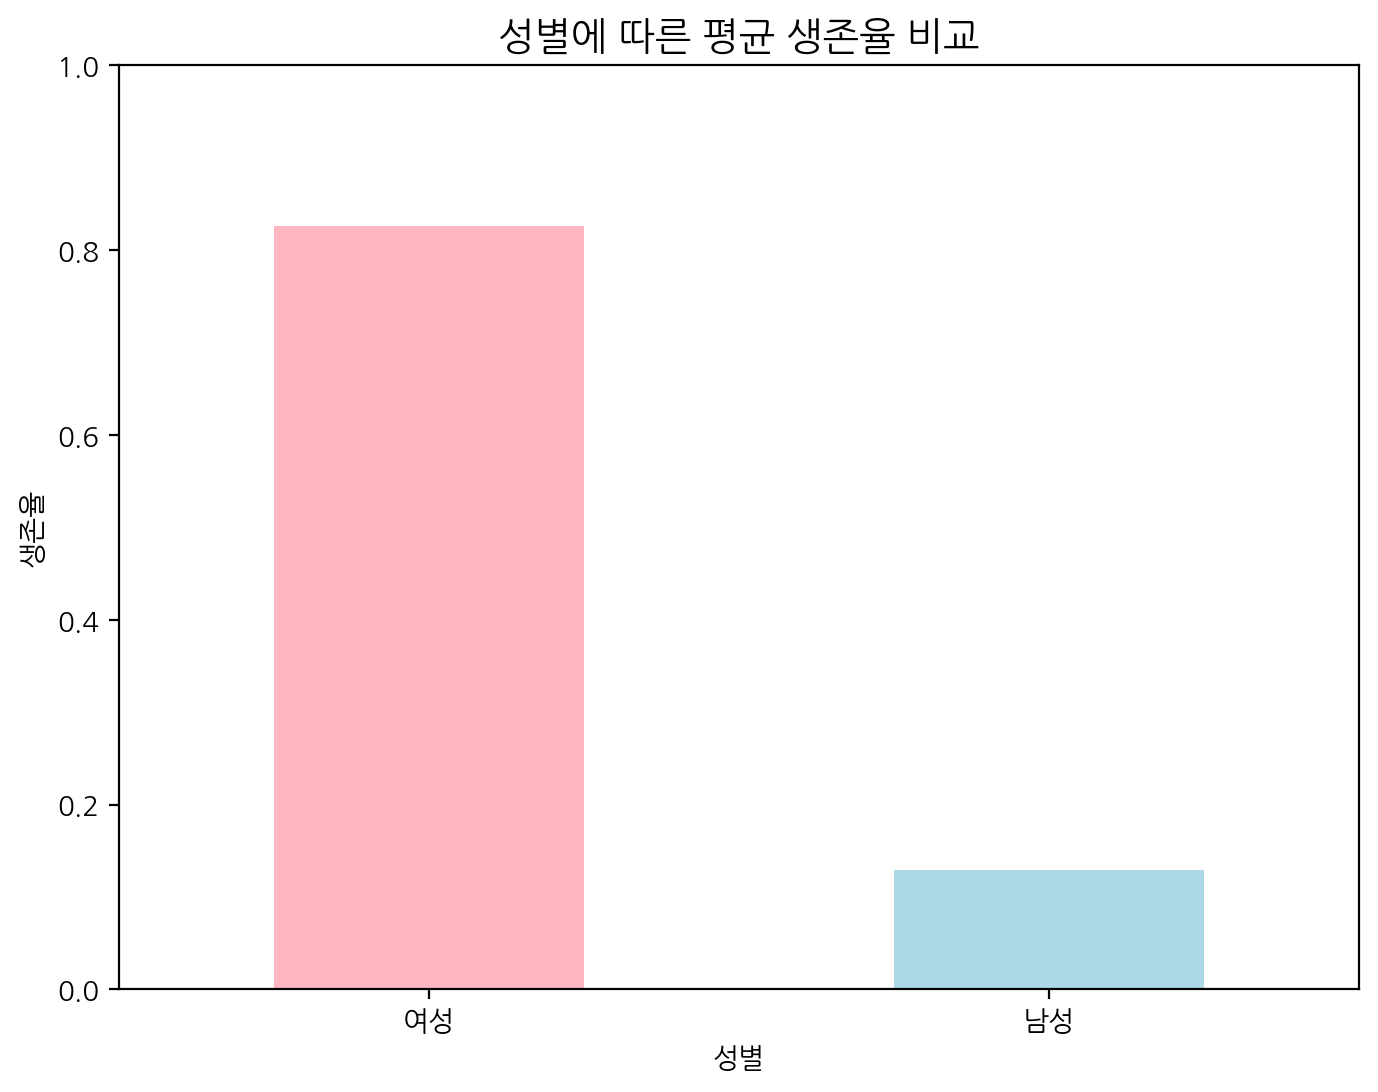

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 막대그래프(bar)로 변경
ax = survival_gender.plot(kind='bar', color=['lightpink', 'lightblue'], rot=0)

# 그래프를 예쁘게 꾸미기 위한 설정
plt.title('성별에 따른 평균 생존율 비교', fontsize=14)
plt.xlabel('성별')
plt.ylabel('생존율')
plt.xticks([0, 1], ['여성', '남성']) # x축 이름을 한글로 보기 쉽게 변경
plt.ylim(0, 1) # y축 범위를 0에서 1(100%)로 고정
plt.show()

### 객실등급에 따른 생존 여부

In [14]:
survival_class = t1.groupby('객실등급')['생존여부'].mean()
survival_class

,생존여부
객실등급,
1,0.575851
2,0.422383
3,0.269394


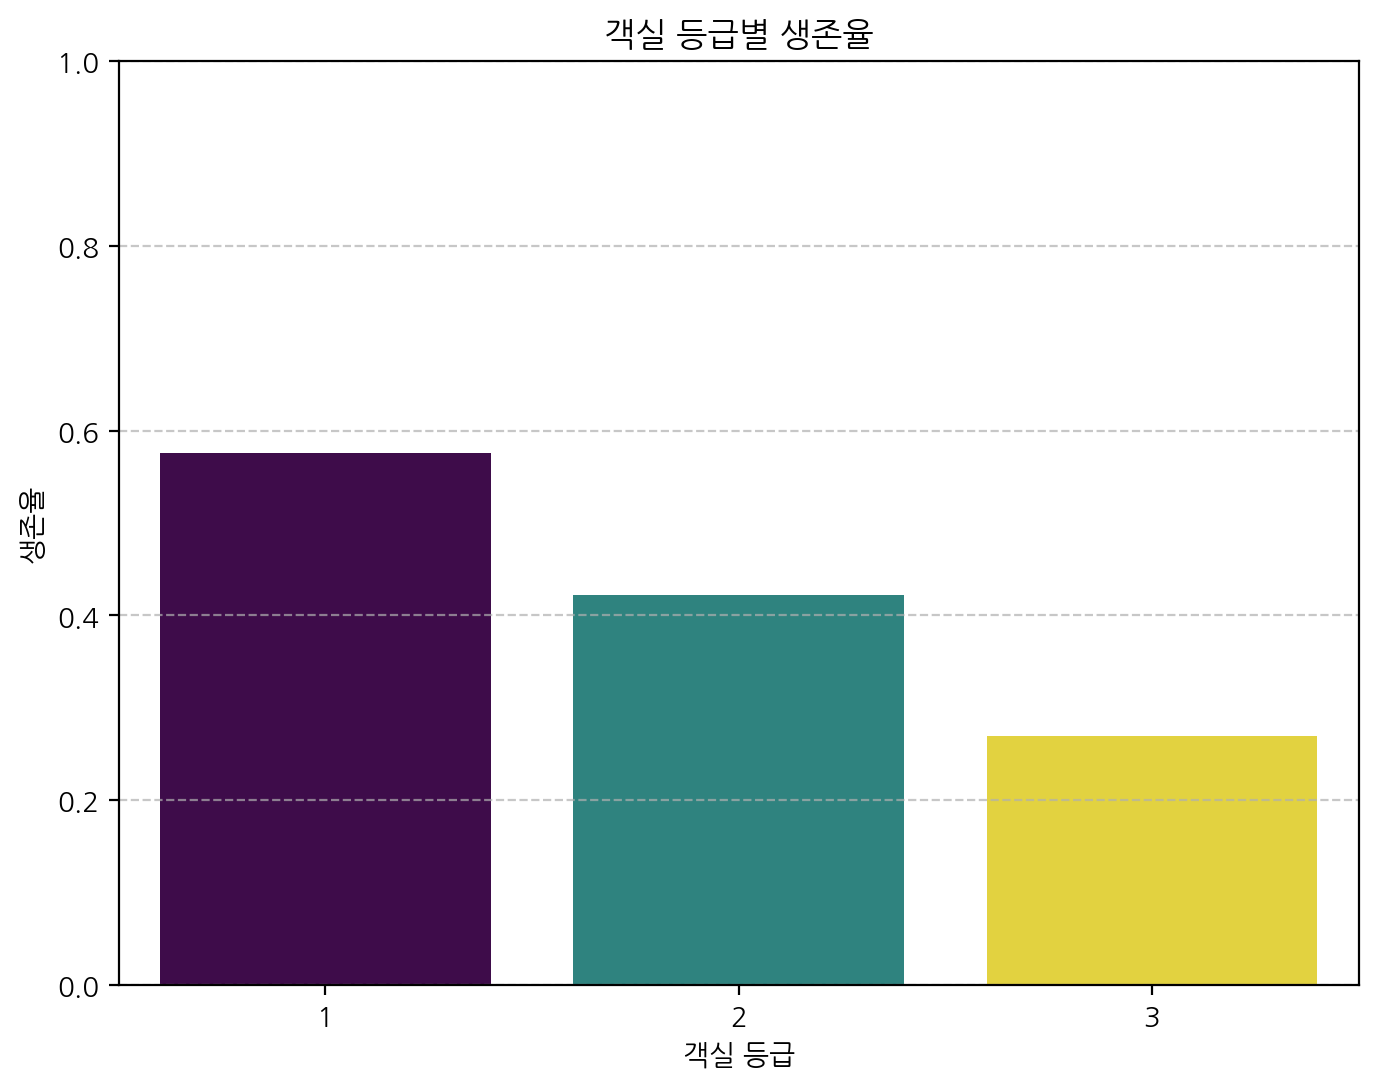

In [15]:
plt.figure(figsize=(8, 6))
sns.barplot(x=survival_class.index, y=survival_class.values, palette='viridis', hue=survival_class.index, legend=False)
plt.title('객실 등급별 생존율')
plt.xlabel('객실 등급')
plt.ylabel('생존율')
plt.ylim(0, 1) # 생존율은 0에서 1 사이이므로 y축 범위 설정
plt.xticks(rotation=0) # x축 라벨 회전 방지
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 동행자수에 따른 생존여부

In [16]:
# 가족
t1['동행자수'] = t1['부모/자식의 수'] + t1['자매/배우자의 수']
t1[['동행자수']]

,동행자수
0,1
1,1
2,0
3,1
4,0
...,...
1304,0
1305,0
1306,0
1307,0


In [17]:
t1['동행여부'] = 0
t1.loc[t1['동행자수'] >= 1, '동행여부'] = 1

t1.groupby('동행여부')['생존여부'].mean()

,생존여부
동행여부,
0,0.292405
1,0.506744


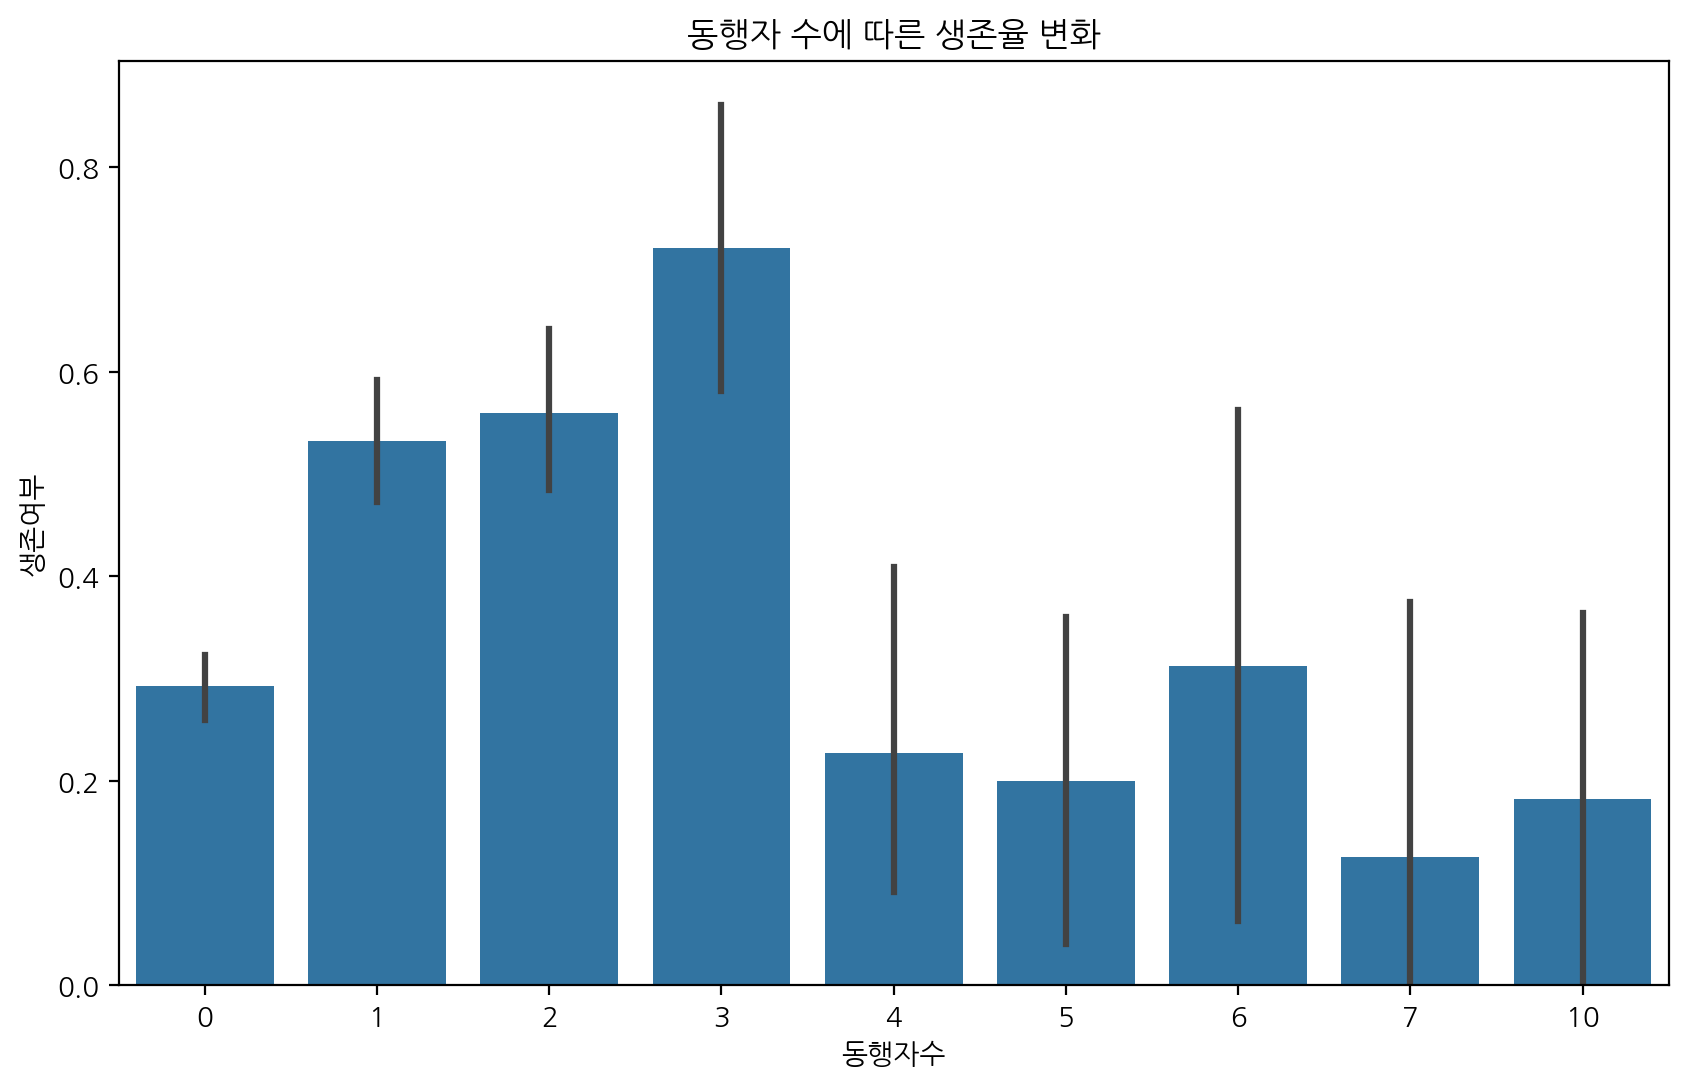

In [18]:
# 동행자 수에 따른 생존

plt.figure(figsize=(10, 6))
sns.barplot(data=t1, x='동행자수', y='생존여부')
plt.title('동행자 수에 따른 생존율 변화')
plt.show()

### 나이에 따른 생존여부

In [19]:
# 나이 분포를 위해 다시 불러옴
t2 = t.copy()
t2

,생존여부,객실등급,성별,나이,자매/배우자의 수,부모/자식의 수,요금,탑승지
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
1304,0,3,male,NaN,0,0,8.0500,S
1305,1,1,female,39.0,0,0,108.9000,C
1306,0,3,male,38.5,0,0,7.2500,S
1307,0,3,male,NaN,0,0,8.0500,S


In [20]:
# 나이에 관한 결측값 제외
t2.dropna(subset = ['나이'], inplace=True)
t2

,생존여부,객실등급,성별,나이,자매/배우자의 수,부모/자식의 수,요금,탑승지
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
1300,1,3,female,3.0,1,1,13.7750,S
1302,1,1,female,37.0,1,0,90.0000,Q
1303,1,3,female,28.0,0,0,7.7750,S
1305,1,1,female,39.0,0,0,108.9000,C


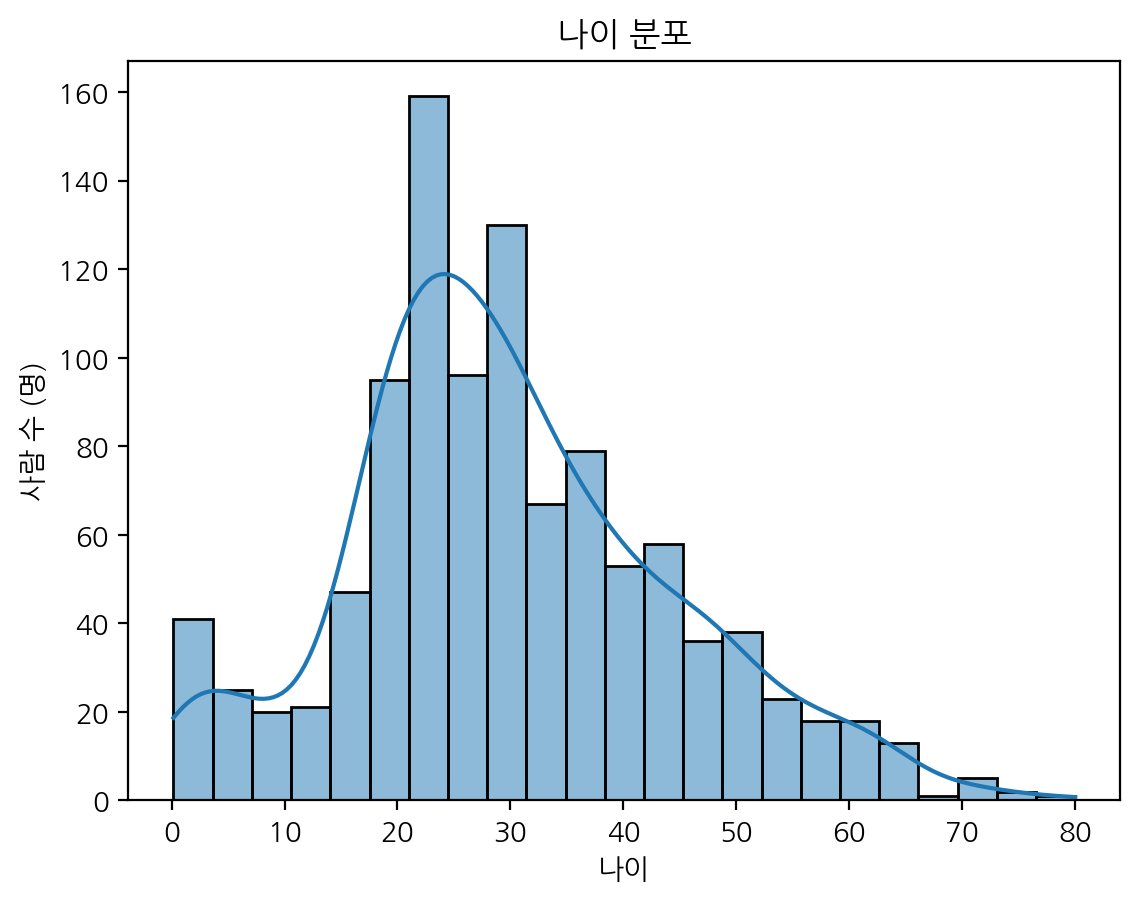

In [21]:
# 나이 분포 확인
sns.histplot(t2['나이'], kde=True)
plt.title("나이 분포")
plt.ylabel("사람 수 (명)")
plt.show()

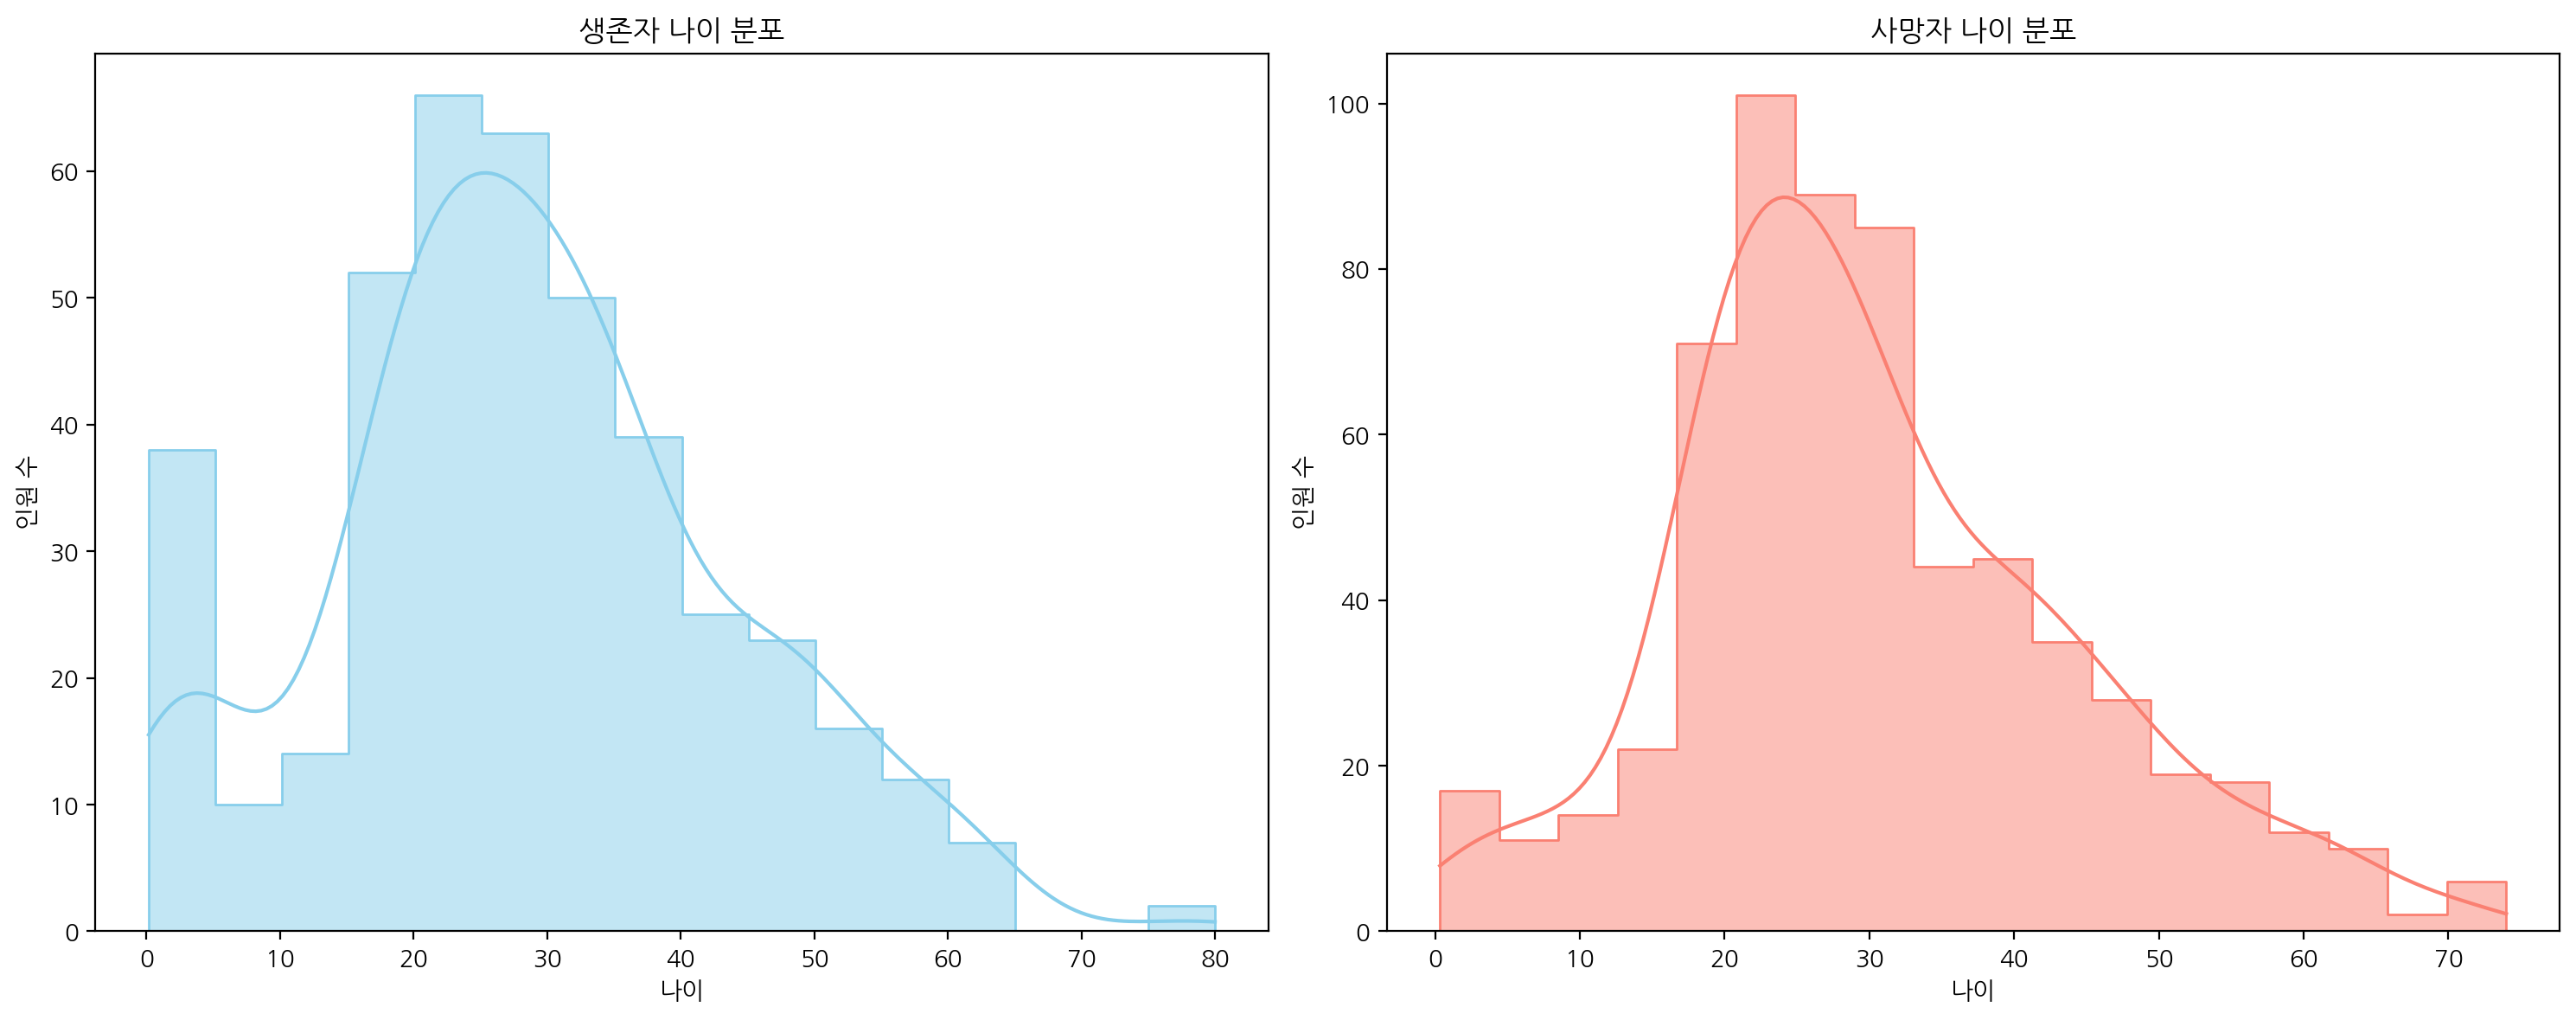

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 생존자와 사망자 데이터를 분리
survived_data = t2[t2['생존여부'] == 1]
dead_data = t2[t2['생존여부'] == 0]

plt.figure(figsize=(15, 6))

# 생존자 나이 분포 히스토그램
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
sns.histplot(data=survived_data, x='나이', kde=True, element='step', color='skyblue')
plt.title('생존자 나이 분포')
plt.xlabel('나이')
plt.ylabel('인원 수')

# 사망자 나이 분포 히스토그램
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
sns.histplot(data=dead_data, x='나이', kde=True, element='step', color='salmon')
plt.title('사망자 나이 분포')
plt.xlabel('나이')
plt.ylabel('인원 수')

plt.tight_layout() # 서브플롯 간의 간격 조정
plt.show()

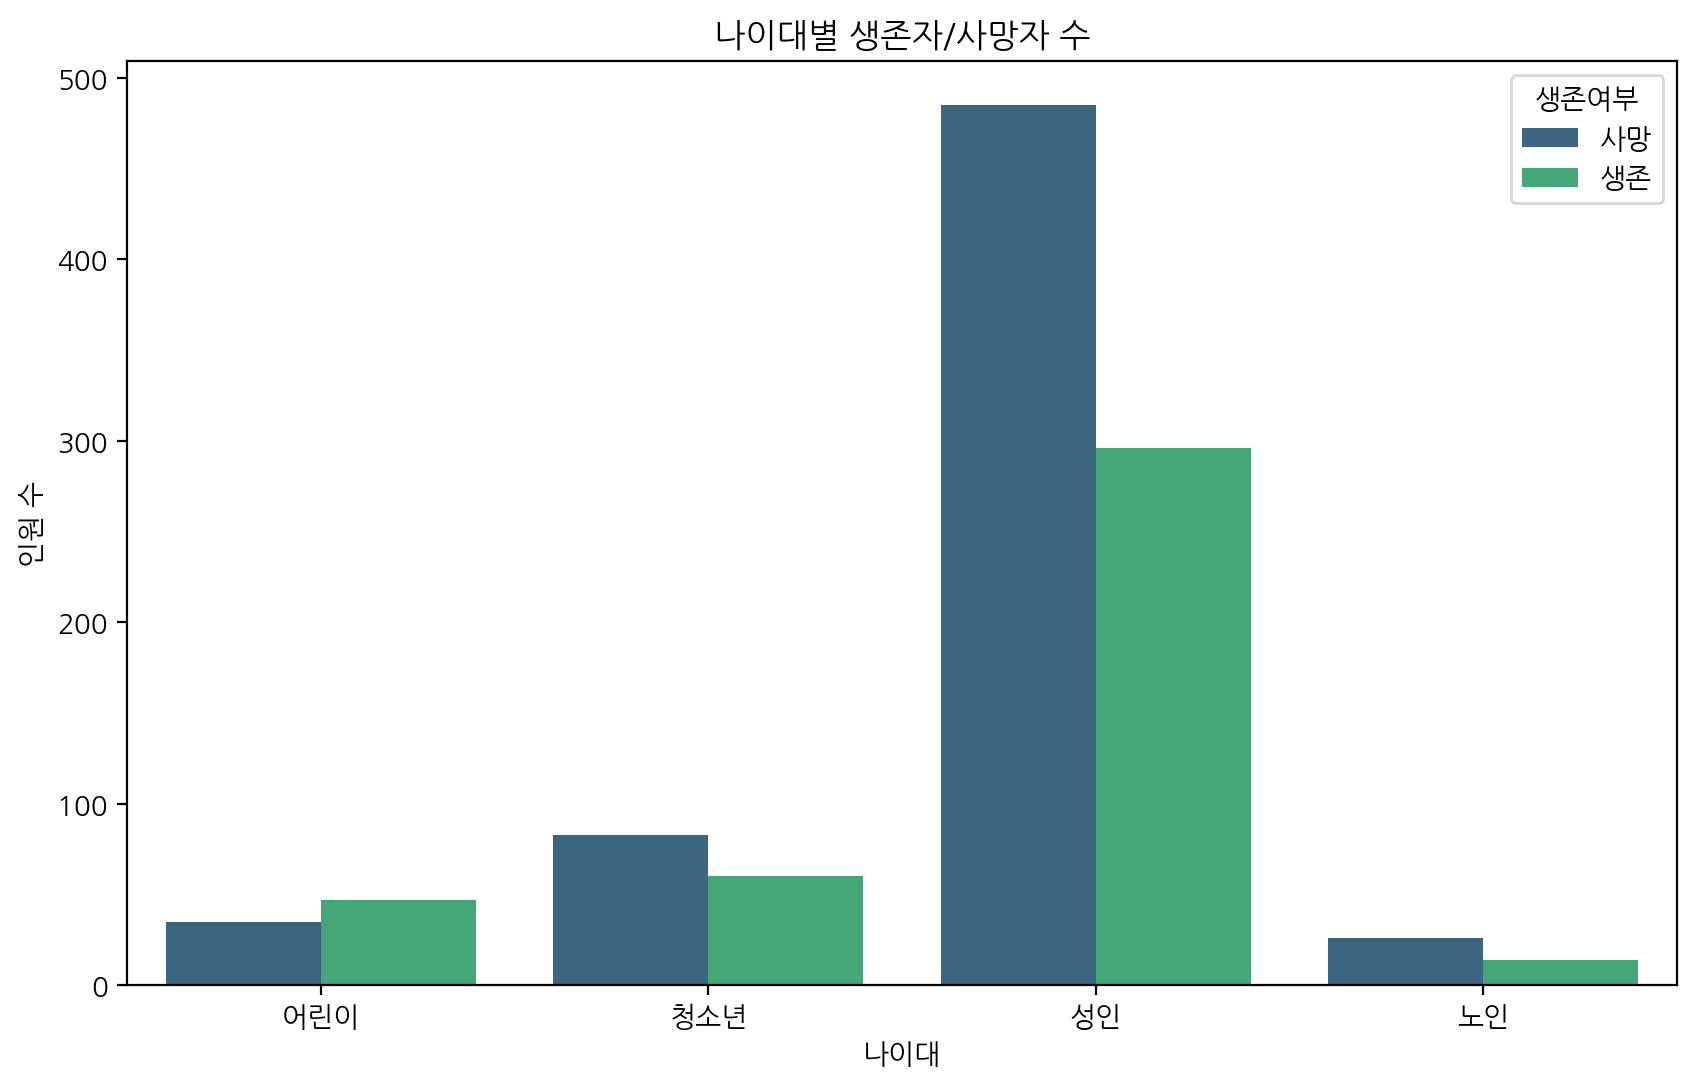

In [23]:
# 나이대 분류 함수 정의 및 적용 (06w 원리)
def get_age_group(age):
    if age < 10: return '어린이'
    elif age < 20: return '청소년'
    elif age < 60: return '성인'
    else: return '노인'

t2['나이대'] = t2['나이'].apply(get_age_group)

# 나이대별 생존율 시각화
plt.figure(figsize=(10, 6))
sns.countplot(data=t2, x='나이대', hue='생존여부', palette='viridis', order=['어린이', '청소년', '성인', '노인'])
plt.title('나이대별 생존자/사망자 수')
plt.xlabel('나이대')
plt.ylabel('인원 수')
plt.legend(title='생존여부', labels=['사망', '생존'])
plt.show()

### 나이와 요금에 따른 생존관계

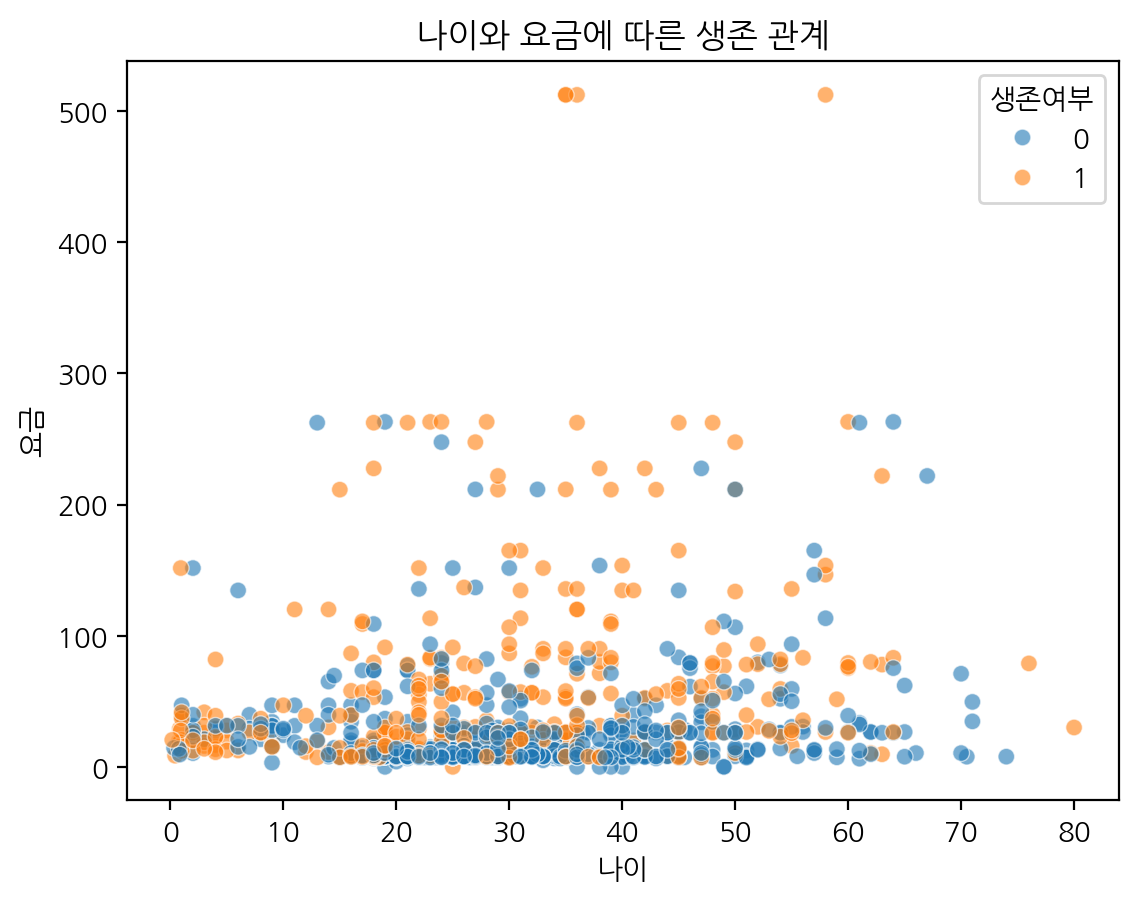

In [24]:
sns.scatterplot(data=t2, x='나이', y='요금', hue='생존여부', alpha=0.6)

plt.title('나이와 요금에 따른 생존 관계')
plt.xlabel('나이')
plt.ylabel('요금')
plt.show()